## 2.Probability density function: to find probability density

In [6]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  numpy.random import normal 

**1. Parametric approach**

In [8]:
sample = normal(loc=50, scale=3, size=1000)    
# assume sample which has size 0f 1000 values jiska normal distribution hoga jisme mean=50 and standard deviation=3, we assume mean ans std. deviation 

In [9]:
sample.mean()

np.float64(49.86067258075905)

(array([  3.,  35.,  91., 195., 291., 235., 107.,  32.,   8.,   3.]),
 array([40.52480066, 42.55785437, 44.59090807, 46.62396178, 48.65701549,
        50.69006919, 52.7231229 , 54.7561766 , 56.78923031, 58.82228401,
        60.85533772]),
 <BarContainer object of 10 artists>)

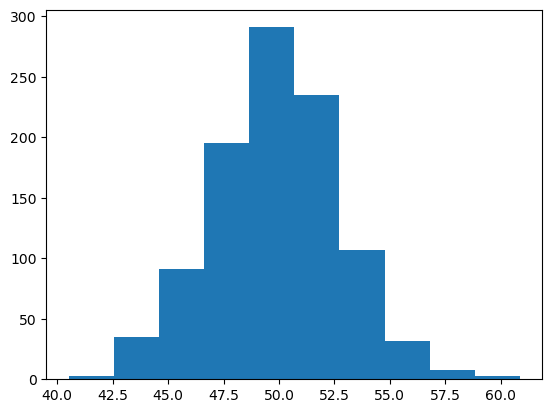

In [11]:
#plot histogram to understand distribution of data"

plt.hist(sample, bins=10)    # by look yeh lag rha hai ki normal distribution ho skta hai

In [12]:
#now calculate sample mean and sample std:

sample_mean = sample.mean()
sample_std = sample.std()

In [13]:
# Main step: now we fitting the distributions with above parameter:

from scipy.stats import norm
dist = norm(sample_mean, sample_std)

In [14]:
values = np.linspace(sample.min(), sample.max(),100)    #100 datapoints genrate krke pdf function mein bhejna hai 

In [15]:
# prob_density find krna : as 100 datapoints pdf ko bbhejne hai so loop chalega:

prob_density = [dist.pdf(value) for value in values]

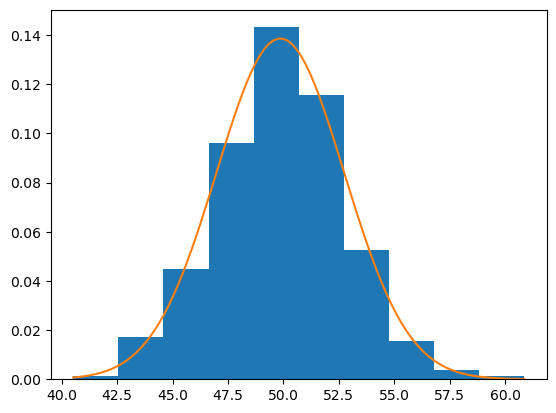

In [17]:
# now plot histogram and pdf

plt.hist(sample, bins=10, density = True)
plt.plot(values, prob_density)   # pdf with x axis as values and y axis as prob_density

**if we use seaborn instead of matplotlib:**

C:\Users\adity\AppData\Local\Temp\ipykernel_3356\1950040031.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

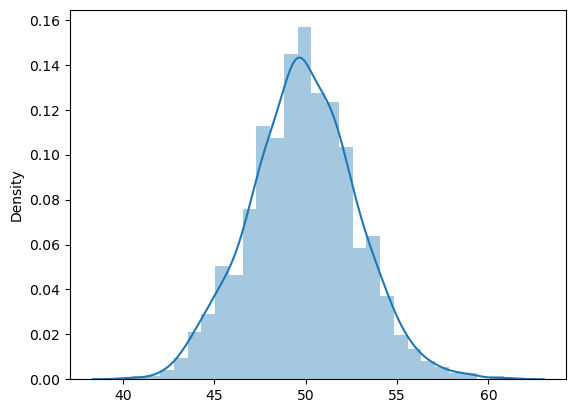

In [21]:
sns.distplot(sample)

**2. Non-parametric approach: KDE PLOT**: as considering bimodial to 2 samples le lenge

In [24]:
# Generate samples:

sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

(array([ 1.,  0.,  0.,  2.,  1.,  0.,  6.,  6., 13.,  9., 18., 20., 22.,
        30., 21., 33., 20., 18., 17., 18., 19., 10., 12.,  8.,  8.,  9.,
        19., 29., 22., 46., 39., 53., 74., 53., 48., 61., 56., 41., 35.,
        31., 23., 17., 16.,  4.,  6.,  1.,  2.,  1.,  0.,  2.]),
 array([ 3.65765509,  4.73342043,  5.80918578,  6.88495113,  7.96071647,
         9.03648182, 10.11224716, 11.18801251, 12.26377786, 13.3395432 ,
        14.41530855, 15.49107389, 16.56683924, 17.64260458, 18.71836993,
        19.79413528, 20.86990062, 21.94566597, 23.02143131, 24.09719666,
        25.17296201, 26.24872735, 27.3244927 , 28.40025804, 29.47602339,
        30.55178873, 31.62755408, 32.70331943, 33.77908477, 34.85485012,
        35.93061546, 37.00638081, 38.08214616, 39.1579115 , 40.23367685,
        41.30944219, 42.38520754, 43.46097288, 44.53673823, 45.61250358,
        46.68826892, 47.76403427, 48.83979961, 49.91556496, 50.99133031,
        52.06709565, 53.142861  , 54.21862634, 55.29439169,

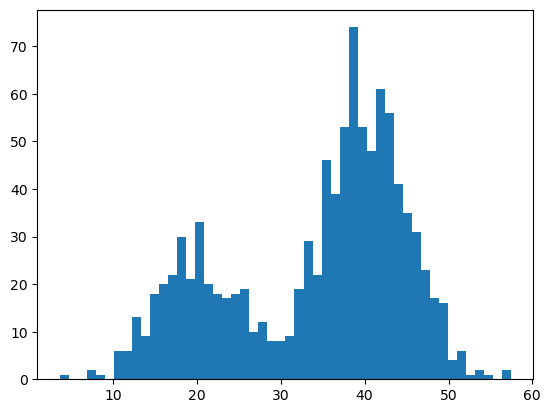

In [25]:
#plot histogram:

plt.hist(sample, bins=50)

In [26]:
# so above koi particular distribution to nhi hai so KDE bamnayenge 
#for making kernels:

from sklearn.neighbors import KernelDensity
model= KernelDensity(bandwidth=3, kernel="gaussian")

In [28]:
# Convert data into 2D array: beacuse ML algoritm 2D data pe work krte hain
sample = sample.reshape((len(sample),1))
model.fit(sample)     # it means usne vo individual kernels banake unki y values ko add krke kde banadiya that we discussed in notes

,bandwidth,3
,algorithm,'auto'
,kernel,'gaussian'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


In [30]:
values = np.linspace(sample.min(), sample.max(), 100)
values = values.reshape((len(values),1))  # again make 2D

In [31]:
prob_density = model.score_samples(values)

**ab jo bhi outcome aaya we came to know that it is log form jo y chahiya tha uska log value mil rha hai so we add exponential to the outcome**

In [32]:
prob_density = np.exp(prob_density)

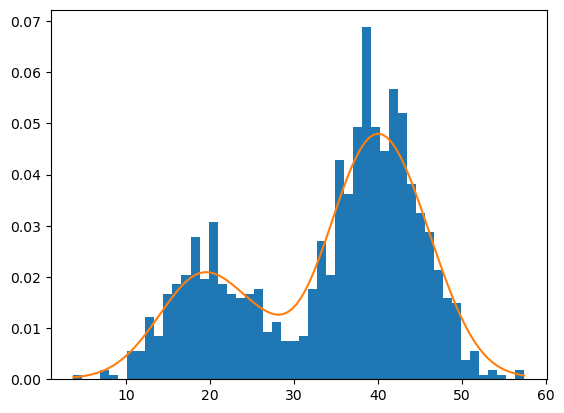

In [34]:
#now plot histogram and KDE plot:

plt.hist(sample, bins=50, density=True)
plt.plot(values[:], prob_density)
plt.show()

**Seaborn:**

<Axes: ylabel='Density'>

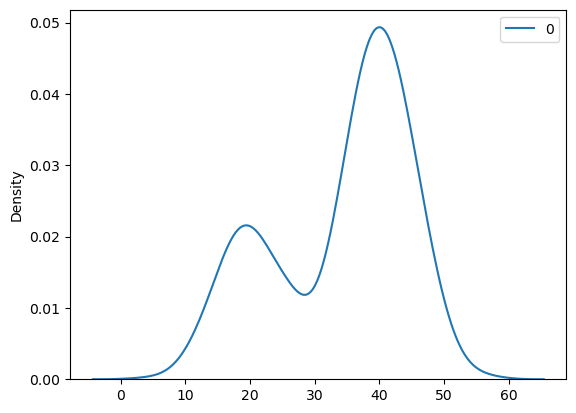

In [36]:
sns.kdeplot(sample.reshape(1000,1))